## General Information
**Name** : Tien Dat Hoang

**Student ID** : 224902565 - Senior

**Company**: Chameleon's Data Science

**Term** : T1 2026

**Sub-project**: Project 3A - Traffic Congestion Prediction System

**Level**: Intermediate

**Pre-requisite skills**: Feature Engineering, Data Cleaning, Data Analytics, Data Visualization. 


## Use Case Description

In a busy city like Melbourne, traffic congestion is not always driven purely by the number of vehicles on the road—unexpected disruptions such as road crashes can significantly affect how traffic flows. Even a single incident can reduce road capacity, create delays, and trigger congestion that spreads across surrounding areas. While many existing systems rely on traffic volume alone, they often overlook how critical these disruptions are in shaping real-world traffic conditions.

In this use case, the focus is on understanding the role of traffic crashes as an early signal for potential congestion. At the current stage of the project, the work is centred solely on the crash dataset. This involves performing thorough data preprocessing—such as cleaning, feature engineering, and temporal extraction—and developing a machine learning model to identify patterns in when and where crashes are more likely to occur. By modelling crash likelihood and frequency, the system begins to capture one of the key drivers behind congestion.

This serves as a foundational phase of the broader project. The next step will be to integrate traffic count data, allowing the model to directly link crash events with actual congestion levels. However, starting with crash data alone provides valuable insights and establishes a strong baseline model. Ultimately, this staged approach ensures that each component is well understood before building a more comprehensive, data-driven traffic congestion prediction system that reflects the complexities of urban mobility

## Preprocessing pipeline

### Importing dataset and standardise column names

In [3]:
import pandas as pd

df = pd.read_csv("victoria_road_crash_data.csv", low_memory=False)

# Clean column names
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(r"[^a-z0-9]+", "_", regex=True)
              .str.strip("_")
)
print(df)

            id   accident_no accident_date accident_time  accident_type  \
0            1  T20150001493    2015-01-22      09:24:00              1   
1            2  T20230006766    2023-03-11      05:40:00              6   
2            3  T20220014167    2022-06-23      15:05:00              4   
3            4  T20200019880    2020-11-10      10:15:00              1   
4            5  T20170021928    2017-04-08      09:45:00              8   
...        ...           ...           ...           ...            ...   
194432  194433  T20170009062    2017-05-08      10:00:00              1   
194433  194434  T20180002451    2018-02-08      16:00:00              1   
194434  194435  T20190003665    2019-02-25      13:15:00              1   
194435  194436  T20130010099    2013-05-15      09:30:00              4   
194436  194437  T20230026924    2023-11-02      08:40:00              1   

                       accident_type_desc  day_of_week day_week_desc  \
0                  Collisio

After loading the file, the column names are cleaned by trimming spaces, converting everything to lowercase, and replacing special characters with underscores. tandardising names improves readability, reduces the chance of typing mistakes, and makes the workflow more professional and reproducible

### Check missing values

In [6]:
df.isnull().sum()

id                       0
accident_no              0
accident_date            0
accident_time            0
accident_type            0
accident_type_desc       0
day_of_week              0
day_week_desc            0
dca_code                 0
dca_desc                 0
light_condition          0
node_id                  0
no_of_vehicles           0
no_persons_killed        0
no_persons_inj_2         0
no_persons_inj_3         0
no_persons_not_inj       0
no_persons               0
police_attend            0
road_geometry            0
road_geometry_desc       0
severity                 0
speed_zone               0
rma                   8763
dtype: int64

### Drop unnecessary columns

In [8]:
df = df.drop(columns=[
    "rma",
    "accident_type",
    "day_of_week",
    "road_geometry",
    "dca_code",
])

This cell removes several columns: `accident_type`, `day_of_week`, `road_geometry`, `dca_code`, and `rma`. The logic behind this is not just about reducing the number of columns, but about improving the usefulness of the dataset for later modelling and analysis. Some of these variables were redundant because they duplicated information already provided in more descriptive columns, such as coded fields alongside readable descriptions.

The `rma` column was also removed because it had a large number of missing values and represented administrative information rather than a feature directly linked to traffic patterns or accident behaviour

### Create datetime variable

In [11]:
# Identify columns 
date_col = "accident_date"
time_col = "accident_time"

# Create datetime
df[time_col] = df[time_col].fillna("00:00").astype(str).str.strip()
df["datetime"] = pd.to_datetime(
    df[date_col].astype(str) + " " + df[time_col],
    errors="coerce",
)
df.head()


,id,accident_no,accident_date,accident_time,accident_type_desc,day_week_desc,dca_desc,light_condition,node_id,no_of_vehicles,no_persons_killed,no_persons_inj_2,no_persons_inj_3,no_persons_not_inj,no_persons,police_attend,road_geometry_desc,severity,speed_zone,datetime
0,1,T20150001493,2015-01-22,09:24:00,Collision with vehicle,Thursday,RIGHT NEAR (INTERSECTIONS ONLY),1,281862,2,0,0,1,2,3,1,T intersection,3,80,2015-01-22 09:24:00
1,2,T20230006766,2023-03-11,05:40:00,Vehicle overturned (no collision),Saturday,OUT OF CONTROL ON CARRIAGEWAY (ON BEND),5,762730,1,0,0,1,0,1,2,Not at intersection,3,100,2023-03-11 05:40:00
2,3,T20220014167,2022-06-23,15:05:00,Collision with a fixed object,Thursday,RIGHT OFF CARRIAGEWAY INTO OBJECT/PARKED VEHICLE,1,719412,1,0,1,2,0,3,1,Y intersection,2,40,2022-06-23 15:05:00
3,4,T20200019880,2020-11-10,10:15:00,Collision with vehicle,Tuesday,REAR END(VEHICLES IN SAME LANE),1,29604,2,0,1,0,1,2,1,T intersection,2,70,2020-11-10 10:15:00
4,5,T20170021928,2017-04-08,09:45:00,No collision and no object struck,Saturday,OUT OF CONTROL ON CARRIAGEWAY (ON STRAIGHT),1,37606,1,0,0,2,0,2,2,T intersection,3,60,2017-04-08 09:45:00


This cell combines the separate date and time columns into one proper datetime feature. This is one of the most important preprocessing steps in the notebook because traffic crash data is fundamentally time-based. Without a reliable datetime column, it would be much harder to extract useful temporal features such as hour of day, weekday patterns, or peak period effects. The code first identifies the date and time columns, fills missing times with "00:00" as a default, and then merges the two into one timestamp using pd.to_datetime(). 

Invalid values are coerced to missing, and rows with invalid datetime results are dropped. This is a sensible and practical choice because rows without usable timestamps cannot contribute meaningfully to time-based analysis. The final print statements provide a quick sanity check by showing the shape, columns, sample datetime values, and the overall date range. This cell demonstrates strong logic because it transforms raw inputs into a structured time variable that drives the rest of the project.

### Extract time-based features

In [14]:
df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour
df["day_of_week_num"] = df["datetime"].dt.dayofweek
df["day_of_week_name"] = df["datetime"].dt.day_name()

df["is_weekend"] = df["day_of_week_num"].isin([5, 6]).astype(int)

df["is_peak_hour"] = df["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)
print(df["datetime"].min(), df["datetime"].max())
# print(df["hour"].value_counts().sort_index().head())
print(df[["datetime", "hour", "day_of_week_name", "is_weekend", "is_peak_hour"]].head())


2012-01-01 00:45:00 2025-07-31 22:30:00
             datetime  hour day_of_week_name  is_weekend  is_peak_hour
0 2015-01-22 09:24:00     9         Thursday           0             1
1 2023-03-11 05:40:00     5         Saturday           1             0
2 2022-06-23 15:05:00    15         Thursday           0             0
3 2020-11-10 10:15:00    10          Tuesday           0             0
4 2017-04-08 09:45:00     9         Saturday           1             1


This cell performs feature engineering by extracting time-related variables from the new datetime column. Specifically, it creates `hour`, `day_of_week_num`, `day_of_week_name`, `is_weekend`, and `is_peak_hour`. This is a very important step because machine learning models and exploratory analysis work better when raw timestamps are transformed into interpretable features. Instead of feeding a full datetime directly into a model, this cell breaks the timestamp into components that reflect human traffic behaviour. For example, weekend traffic often differs from weekday traffic, and peak commuting hours are likely to have different accident patterns compared with late night periods. Defining peak hours as 7–9 AM and 4–6 PM is logically reasonable because these periods align with common urban commuting patterns. This cell therefore adds domain knowledge to the dataset. That is valuable because it shifts the work from simple cleaning into meaningful feature construction, which is often a sign of stronger and more thoughtful preprocessing

### Aggregate crashes into accident counts

In [17]:
agg = (
    df.groupby(["date", "hour", "day_of_week_num", "day_of_week_name", "is_weekend", "is_peak_hour"])
      .size()
      .reset_index(name="accident_count")
)
print(agg.head())
print(agg.shape)
print(agg["accident_count"].describe())

         date  hour  day_of_week_num day_of_week_name  is_weekend  \
0  2012-01-01     0                6           Sunday           1   
1  2012-01-01     1                6           Sunday           1   
2  2012-01-01     2                6           Sunday           1   
3  2012-01-01     3                6           Sunday           1   
4  2012-01-01     4                6           Sunday           1   

   is_peak_hour  accident_count  
0             0               2  
1             0               1  
2             0               2  
3             0               1  
4             0               2  
(81200, 7)
count    81200.000000
mean         2.394544
std          1.557468
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         14.000000
Name: accident_count, dtype: float64


### Dataframe inspection after aggregation

In [19]:
print(agg.info())
print(agg.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81200 entries, 0 to 81199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   date              81200 non-null  object
 1   hour              81200 non-null  int32 
 2   day_of_week_num   81200 non-null  int32 
 3   day_of_week_name  81200 non-null  object
 4   is_weekend        81200 non-null  int32 
 5   is_peak_hour      81200 non-null  int32 
 6   accident_count    81200 non-null  int64 
dtypes: int32(4), int64(1), object(2)
memory usage: 3.1+ MB
None
               hour  day_of_week_num    is_weekend  is_peak_hour  \
count  81200.000000     81200.000000  81200.000000  81200.000000   
mean      12.829680         3.018362      0.284323      0.318510   
std        5.922254         1.982210      0.451094      0.465901   
min        0.000000         0.000000      0.000000      0.000000   
25%        8.000000         1.000000      0.000000      0.000000   
50%  

### Accident Count Distribution Boxplot

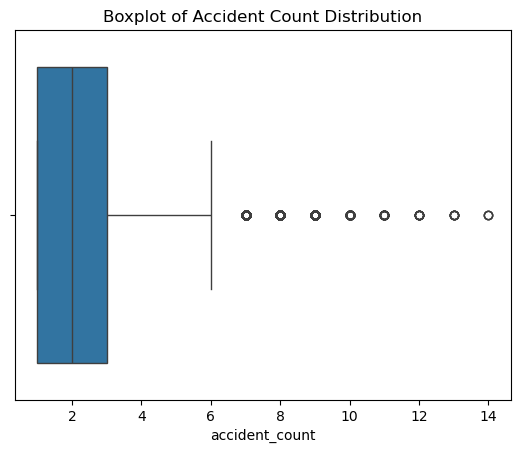

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=agg["accident_count"])
plt.title("Boxplot of Accident Count Distribution")
plt.show()

The boxplot of accident counts reveals a strongly right-skewed distribution, where the majority of observations are concentrated at lower values, while a smaller number of time periods exhibit significantly higher accident counts. These high-value observations appear as outliers beyond the upper whisker, indicating occasional spikes in accident frequency. Rather than being treated as noise, these outliers likely represent meaningful high-risk traffic conditions, such as peak congestion periods or unusual events. Therefore, no outlier removal was performed, as preserving these values is essential for accurately modelling and predicting traffic risk patterns.

### Create accident risk categories

In [24]:
q50 = agg["accident_count"].quantile(0.50)
q80 = agg["accident_count"].quantile(0.80)

def label_risk(x):
    if x <= q50:
        return "Low"
    elif x <= q80:
        return "Medium"
    return "High"

agg["accident_risk"] = agg["accident_count"].apply(label_risk)
print(agg["accident_risk"].value_counts())
print(q50, q80)

accident_risk
Low       51043
Medium    21824
High       8333
Name: count, dtype: int64
2.0 4.0


This cell converts the numerical accident_count into a categorical target variable called accident_risk, with three classes: Low, Medium, and High. The thresholds are defined using the 33rd and 66th percentiles, which split the distribution into roughly balanced groups. The use of quantiles is logical because it avoids manually choosing arbitrary cut-off values and instead bases the labels on the actual data distribution. This makes the method more transparent and reproducible. 

### Bar chart of accident frequency by hour

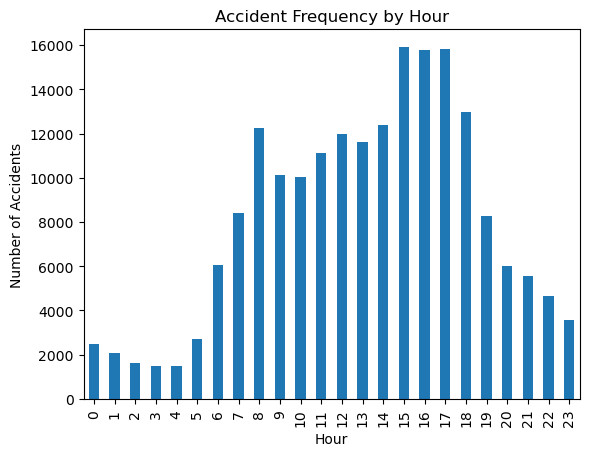

In [27]:

df.groupby("hour").size().plot(kind="bar")

plt.title("Accident Frequency by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.show()

### Heatmap of accident frequency by day and hour

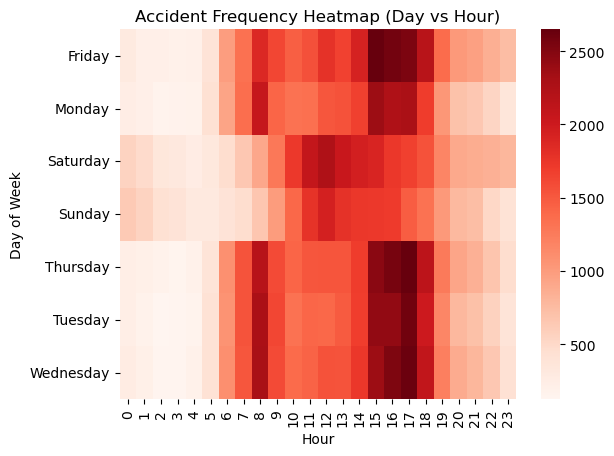

In [29]:
import seaborn as sns

heatmap_data = df.groupby(["day_of_week_name", "hour"]).size().unstack()

plt.figure()
sns.heatmap(heatmap_data, cmap="Reds")

plt.title("Accident Frequency Heatmap (Day vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.show()

### Bar chart of accident risk distribution

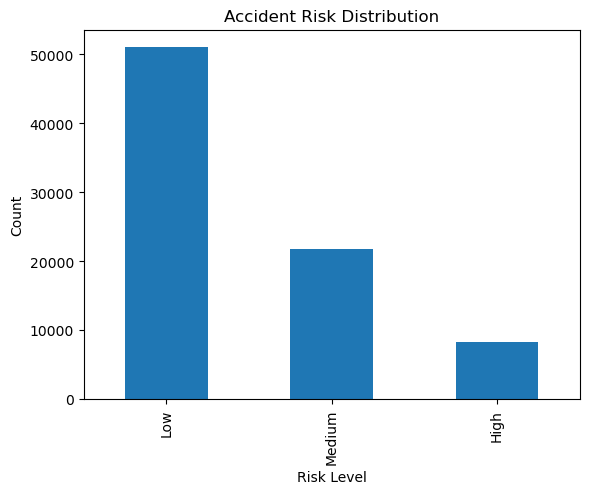

In [31]:
agg["accident_risk"].value_counts().plot(kind="bar")

plt.title("Accident Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

## Building Model

### Select features and target

In [34]:
# Features and target
X = agg.drop(columns=["accident_risk","accident_count"])
y = agg["accident_risk"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (81200, 6)
Target shape: (81200,)

Target distribution:
accident_risk
Low       51043
Medium    21824
High       8333
Name: count, dtype: int64


### Drop columns not suitable for modeling

In [36]:
# Drop columns that may cause leakage or are not suitable for direct modeling
X_model = X.drop(columns=["day_of_week_name"], errors="ignore")

print(X_model.columns)

Index(['date', 'hour', 'day_of_week_num', 'is_weekend', 'is_peak_hour'], dtype='object')


### Identify numeric and categorical columns

In [38]:
# Identify feature types
categorical_cols = X_model.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_model.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['date']
Numeric columns: ['hour', 'day_of_week_num', 'is_weekend', 'is_peak_hour']


### Train/test split

In [40]:
## Train/ Test Split
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

X_train: (64960, 5)
X_test: (16240, 5)

Training target distribution:
accident_risk
Low       0.628618
Medium    0.268765
High      0.102617
Name: proportion, dtype: float64

Testing target distribution:
accident_risk
Low       0.628571
Medium    0.268781
High      0.102648
Name: proportion, dtype: float64


### Build preprocessing transformer

In [42]:
## Build 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing for numeric and categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['hour', 'day_of_week_num', 'is_weekend',
                                  'is_peak_hour']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['date'])])

### Logistic Regression Model

In [44]:
from sklearn.linear_model import LogisticRegression

# Baseline model pipeline
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, multi_class="multinomial"))
])

# Train
logreg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

C:\Users\hdat2\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression model trained successfully.


### Evaluate Logistic Regression

In [46]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict
y_pred_logreg = logreg_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_logreg))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_logreg))

Accuracy: 0.6162561576354679

Classification Report:

              precision    recall  f1-score   support

        High       0.31      0.04      0.07      1667
         Low       0.65      0.92      0.76     10208
      Medium       0.35      0.13      0.19      4365

    accuracy                           0.62     16240
   macro avg       0.44      0.36      0.34     16240
weighted avg       0.53      0.62      0.54     16240

Confusion Matrix:

[[  68 1278  321]
 [  72 9359  777]
 [  82 3702  581]]


Logistic Regression achieved moderate overall accuracy but performed poorly on minority classes, particularly High-risk instances. This is due to its linear nature, which limits its ability to capture complex relationships between temporal features and accident risk levels. The model tends to favour the dominant Low-risk class, resulting in high recall for Low but very low recall for High. This indicates that Logistic Regression is not well-suited for this problem, as traffic risk patterns are likely influenced by nonlinear interactions between features.

In [48]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=10,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

# Train
rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['hour', 'day_of_week_num',
                                                   'is_weekend',
                                                   'is_peak_hour']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['date'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        min_samples_split=10, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [49]:
# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.5030788177339901

Classification Report:

              precision    recall  f1-score   support

        High       0.20      0.52      0.29      1667
         Low       0.78      0.58      0.66     10208
      Medium       0.33      0.33      0.33      4365

    accuracy                           0.50     16240
   macro avg       0.44      0.47      0.43     16240
weighted avg       0.60      0.50      0.53     16240

Confusion Matrix:

[[ 867  310  490]
 [1882 5879 2447]
 [1586 1355 1424]]


In [50]:
# Convert report to dict
report = classification_report(y_test, y_pred_rf, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Round values
report_df = report_df.round(3)

print(report_df)

              precision  recall  f1-score    support
High              0.200   0.520     0.289   1667.000
Low               0.779   0.576     0.662  10208.000
Medium            0.327   0.326     0.326   4365.000
accuracy          0.503   0.503     0.503      0.503
macro avg         0.435   0.474     0.426  16240.000
weighted avg      0.598   0.503     0.534  16240.000


The Random Forest model achieved a lower overall accuracy compared to Logistic Regression; however, it significantly improved performance on minority classes. In particular, recall for High-risk instances increased from 4% to 51%, demonstrating the model’s ability to better identify critical traffic conditions. While this improvement comes at the cost of reduced accuracy, it reflects a more balanced and realistic classification behaviour. This highlights the limitation of accuracy as a sole evaluation metric in imbalanced datasets and emphasises the importance of recall and F1-score when detecting high-risk scenarios.